In [18]:
import numpy as np
from hackrf import HackRF
import time
import matplotlib.pyplot as plt
from datetime import datetime
import os
from scipy.signal import stft

In [19]:
# Setup save directory and timestamped filename for binary .dat (complex64 interleaved)
main_dir = "/home/cubesat/vscode/Proj1/data/iq"

# get newest file
dat_file = max(
    (os.path.join(main_dir, f) for f in os.listdir(main_dir)),
    key=os.path.getmtime
)

# Read raw int8 IQ data
raw = np.fromfile(dat_file, dtype=np.int8)

# Convert to complex64
iq = raw[0::2].astype(np.float32) + 1j * raw[1::2].astype(np.float32)

# keep only the middle third of the IQ buffer
#L = len(iq)
#start = L // 3 *2
#end = start * 3
#iq = iq[:start].copy()


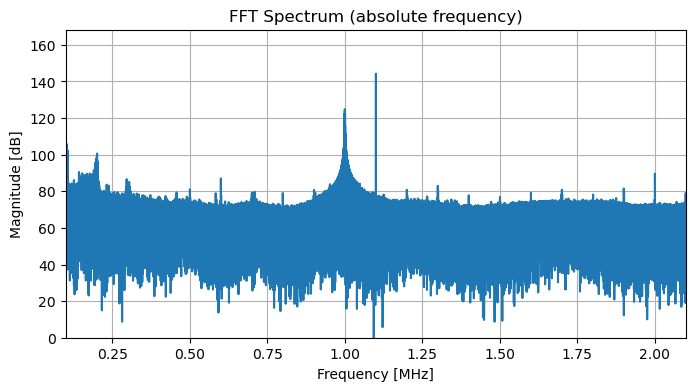

In [21]:
# --- FFT ---
center_freq = 1.1e6  # Center frequency in Hz (absolute)
sample_rate =5_000_000  # Sample rate in Hz
N = len(iq)
spectrum = np.fft.fftshift(np.fft.fft(iq))
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/sample_rate))  # baseband frequencies (Hz)
# Convert to absolute frequency by adding center_freq
freqs_abs = center_freq + freqs

# --- Plot ---
plt.figure(figsize=(8,4))
plt.plot(freqs_abs/1e6, 20*np.log10(np.abs(spectrum) + 1e-6))
plt.title("FFT Spectrum (absolute frequency)")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Magnitude [dB]")
plt.grid(True)

# set x-axis range example: center_freq +/- 1 MHz
plt.xlim((center_freq - 1e6)/1e6, (center_freq + 1e6)/1e6)
plt.ylim(0, np.max(20*np.log10(np.abs(spectrum))) + 10)
plt.show()


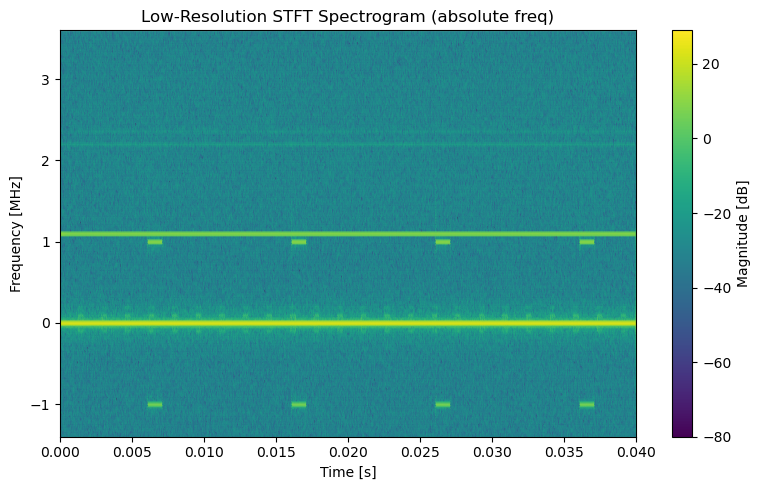

STFT shape = (256, 1564), time frames = 1564, freq bins = 256


In [65]:
from scipy.signal import stft
from numpy.fft import fftshift
import matplotlib.pyplot as plt
import numpy as np

# Downsample and shorten for speed
# iq_ds = iq[start_idx-100_000:start_idx+400_000]      # only first 200k samples, every 20th
iq_ds = iq[:200_000]
fs = sample_rate         # adjust sample rate

# STFT parameters
nperseg = 256
noverlap = nperseg // 2
window = 'hann'

# Compute STFT
f, t, Zxx = stft(iq_ds, fs=fs, window=window, nperseg=nperseg,
                 noverlap=noverlap, return_onesided=False)

# Shift and convert to dB
Zxx_shift = fftshift(Zxx, axes=0)
f_shift = fftshift(f)
# Convert to absolute frequency by adding center_freq (if set above)
f_shift_abs = center_freq + f_shift
Sxx = 20 * np.log10(np.abs(Zxx_shift) + 1e-12)

# Plot
plt.figure(figsize=(8,5))
plt.pcolormesh(t, f_shift_abs/1e6, Sxx, shading='gouraud', cmap='viridis')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [MHz]')
plt.title('Low-Resolution STFT Spectrogram (absolute freq)')
plt.colorbar(label='Magnitude [dB]')
# Set y-limits centered on center_freq if available
plt.ylim((center_freq - fs/2)/1e6, (center_freq + fs/2)/1e6)
plt.tight_layout()
plt.show()

print(f"STFT shape = {Sxx.shape}, time frames = {len(t)}, freq bins = {len(f)}")


In [82]:
fs = 5_000_000  # Hz
symbol_rate = 100_000  # Hz
symbols_per_block = 1000 # from the transmitted waveform, 100 sym on, 900 sym off
fc = 1.1e6  # Hz
ftone = 1e6  # Hz
samples_per_block = fs // symbol_rate * symbols_per_block

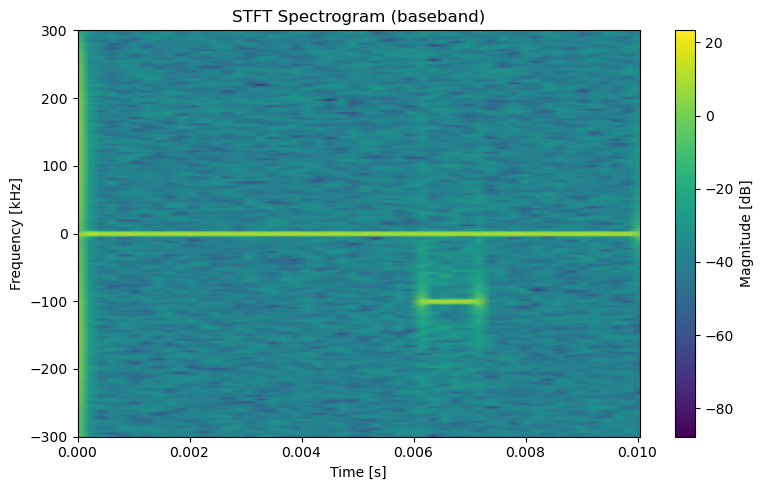

STFT shape = (2048, 50), time frames = 50, freq bins = 2048


In [83]:
from scipy.signal import stft
from numpy.fft import fftshift
import matplotlib.pyplot as plt
import numpy as np

# Shorten for speed
iq_ds = iq[:samples_per_block]
fs = sample_rate

# STFT parameters
nperseg = 2048
noverlap = nperseg // 2
window = 'hann'

# Compute STFT
f, t, Zxx = stft(
    iq_ds,
    fs=fs,
    window=window,
    nperseg=nperseg,
    noverlap=noverlap,
    return_onesided=False
)

# Shift zero frequency to center
Zxx_shift = fftshift(Zxx, axes=0)
f_shift = fftshift(f)

# Magnitude in dB
Sxx = 20 * np.log10(np.abs(Zxx_shift) + 1e-12)

# Plot (BASEBAND frequency axis)
plt.figure(figsize=(8, 5))
plt.pcolormesh(t, f_shift / 1e3, Sxx, shading='gouraud', cmap='viridis')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [kHz]')
plt.title('STFT Spectrogram (baseband)')
plt.colorbar(label='Magnitude [dB]')
plt.ylim(-300, 300)   # optional zoom around DC
plt.tight_layout()
plt.show()

print(f"STFT shape = {Sxx.shape}, time frames = {len(t)}, freq bins = {len(f)}")

Power correlator to get start_idx

In [77]:
fs = 5_000_000  # Hz
symbol_rate = 100_000  # Hz
symbols_per_block = 1000 # from the transmitted waveform, 100 sym on, 900 sym off
fc = 1.1e6  # Hz
ftone = 1e6  # Hz
samples_per_block = fs // symbol_rate * symbols_per_block

iq_block = iq[:samples_per_block]

# -- shift energy near ftone to 0 Hz --
f_offset = ftone - fc  # Hz
n = np.arange(len(iq_block), dtype=np.float64)
lo = np.exp(-1j * 2*np.pi * f_offset * n / fs)
bb = iq_block * lo

# REMOVE DC OFFSET 
bb = bb - np.mean(bb)

print("Mean power:", np.mean(np.abs(bb)**2))
print("First 5 samples:", bb[:5])

sps = int(fs / symbol_rate)   # 50
M = sps                       # moving-average length (try 50)

# Low-pass filter via moving average
h = np.ones(M, dtype=np.float64) / M
bb_lp = np.convolve(bb, h, mode="same")

print()
print("LP mean power:", np.mean(np.abs(bb_lp)**2))
print("First 5 LP samples:", bb_lp[:5])

Mean power: 308.5124199406353
First 5 samples: [1.9672019 -2.30997475j 2.20209777-2.04353768j 2.401748  -1.7497613j
 2.56300398-1.43327861j 2.68332261-1.09908076j]

LP mean power: 1.8840329242018699
First 5 LP samples: [0.71632482+0.49000972j 0.67566886+0.52381022j 0.63031498+0.55228199j
 0.5809681 +0.57487822j 0.52839609+0.59114481j]


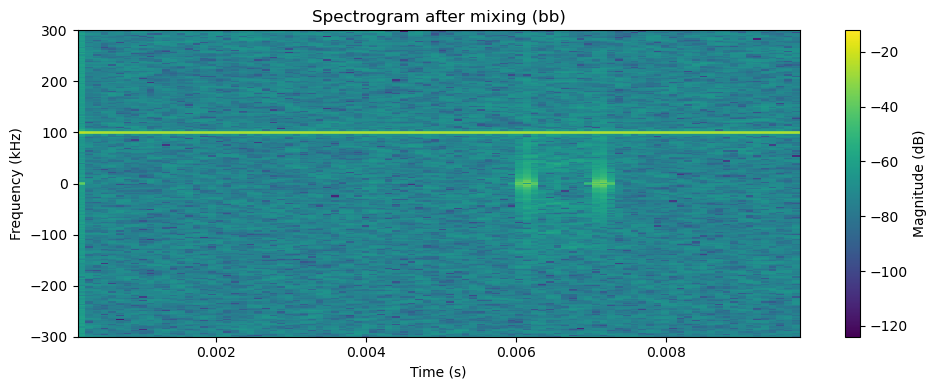

In [78]:
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

f, t, Sxx = spectrogram(
    bb,
    fs=fs,
    window="hann",
    nperseg=2048,
    noverlap=1536,
    return_onesided=False,
    scaling="density",
    mode="magnitude",
)

# Shift zero freq to center
Sxx = np.fft.fftshift(Sxx, axes=0)
f = np.fft.fftshift(f)

plt.figure(figsize=(10, 4))
plt.pcolormesh(t, f / 1e3, 20*np.log10(Sxx + 1e-12), shading="auto")
plt.colorbar(label="Magnitude (dB)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (kHz)")
plt.title("Spectrogram after mixing (bb)")
plt.ylim(-300, 300)   # zoom around DC
plt.tight_layout()
plt.show()


In [72]:
# Power correlator to get start_idx
p = np.abs(bb_lp)**2
on_symbols = 100
win_len = int(on_symbols * sps)   # 100 * 50 = 5000 samples

w = np.ones(win_len, dtype=np.float64)
p_int = np.convolve(p, w, mode="same")   # integrated power

# Threshold + find start index (come back dont understand)
noise_len = int(0.001 * fs)  # 1 ms = 5000 samples
noise_floor = np.median(p_int[:noise_len])
noise_spread = np.median(np.abs(p_int[:noise_len] - noise_floor))  # robust MAD-ish

thr = noise_floor + 10 * noise_spread   # 10 is a decent starting factor

start_idx = int(np.argmax(p_int > thr))  # first True (0 if never crosses)
start_time = start_idx / fs

print("start_idx =", start_idx)
print("start_time =", start_time, "sec")
print("threshold =", thr)

start_idx = 33160
start_time = 0.006632 sec
threshold = 46034.12837969777


In [84]:
# use corrected value

# ---- Option A: delay correction ----
delay = win_len // 2          # group delay of the power correlator
start_idx_corr = start_idx - delay
start_time_corr = start_idx_corr / fs

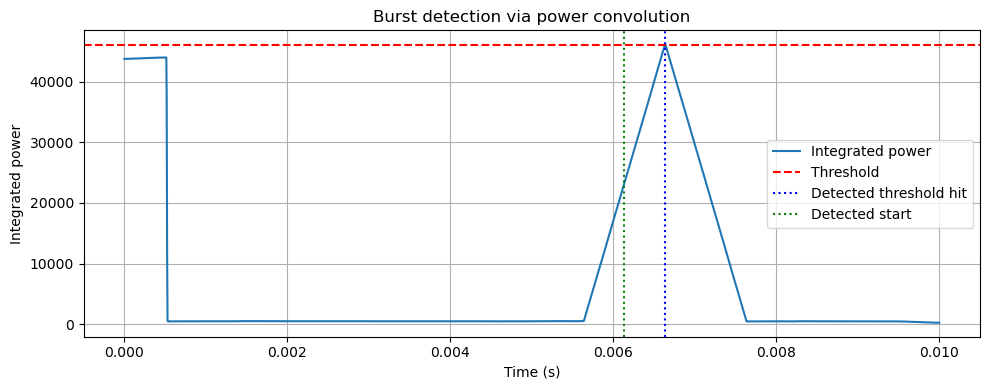

In [87]:
import matplotlib.pyplot as plt

t = np.arange(len(p_int)) / fs

plt.figure(figsize=(10, 4))
plt.plot(t, p_int, label="Integrated power")
plt.axhline(thr, color="r", linestyle="--", label="Threshold")

# Mark detected start (if you have one)
plt.axvline(start_time, color="b", linestyle=":", label="Detected threshold hit")

plt.axvline(start_time_corr, color="g", linestyle=":", label="Detected start")

plt.xlabel("Time (s)")
plt.ylabel("Integrated power")
plt.title("Burst detection via power convolution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [54]:
if not np.any(p_int > thr):
    print("No detection: try increasing gain, widening LPF, or lowering threshold factor.")


No detection: try increasing gain, widening LPF, or lowering threshold factor.
